# **Randomly connected E/I SNN — Visualisation**

Load results saved by `scripts/run_random_ei_snn.py` and plot:
- Stimulation waveform
- Raster plot
- Smoothed PSTH (E and I populations separately)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from pathlib import Path

/var/folders/8s/q649n2z56_1045fkqy4dygm00000gr/T/ipykernel_51047/3861358189.py:3: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  from scipy.ndimage import gaussian_filter1d


In [2]:
# Plot style
plt.rcParams.update({'font.size': 14})
plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
# no box around legends 


In [3]:
# Point this at the specific run directory you want to visualise.
# Set to None to automatically pick the most recent run.

# Lognormal
results_root = Path('../results/random_ei_snn_pulses_lognormal_istim')
run_dir = Path('../results/random_ei_snn_pulses_lognormal_istim/20260414_151422')

# # Uniform (same mean as lognormal)
# results_root = Path('../results/random_ei_snn_pulses_uniform_istim')
# run_dir = Path('../results/random_ei_snn_pulses_uniform_istim/20260414_152528')

# # Uniform (higher mean)
# results_root = Path('../results/random_ei_snn_pulses_uniform_istim')
# run_dir = Path('../results/random_ei_snn_pulses_uniform_istim/20260414_154207')

# # Old results (showing fewer decreasers)
# results_root = Path('../results/random_ei_snn_pulses')
# run_dir = Path('../results/random_ei_snn_pulses/20260402_224038_Cm500pF_gL25nS')

# # New run with old params
# results_root = Path('../results/random_ei_snn_pulses_uniform_istim_Cm500_gL25')
# run_dir = Path('../results/random_ei_snn_pulses_uniform_istim_Cm500_gL25/20260414_155433')

# New run matching O'Rawe params
results_root = Path('../results/random_ei_snn_pulses_lognormal_istim_orawe_params')
run_dir = Path('../results/random_ei_snn_pulses_lognormal_istim_orawe_params/20260414_155828')

# # New run matching O'Rawe params but with gL=25 nS
# results_root = Path('../results/random_ei_snn_pulses_lognormal_istim_orawe_params_gL25')
# run_dir = Path('../results/random_ei_snn_pulses_lognormal_istim_orawe_params_gL25/20260414_161143')

if run_dir is None:
    run_dirs = sorted(results_root.iterdir())
    if not run_dirs:
        raise FileNotFoundError(f'No run directories found in {results_root}')
    run_dir = run_dirs[-1]

print(f'Loading results from: {run_dir}')

Loading results from: ../results/random_ei_snn_pulses_lognormal_istim_orawe_params/20260414_155828


In [4]:
# Define location to save figures
fig_dir = run_dir / 'figures'
fig_dir.mkdir(exist_ok=True)

In [5]:
# Load data
spikes  = np.load(run_dir / 'spike_monitor.npz')
stim    = np.load(run_dir / 'stim_waveform.npz')
params  = np.load(run_dir / 'params.npz')

spike_times   = spikes['spike_times']    # ms
spike_indices = spikes['spike_indices']

dt_ms    = float(stim['dt_ms'])
t_total_ms = float(stim['t_total_ms'])

# Handle both old-style (stim_array 1D) and new-style (timed_input_pA 2D) saves
if 'stim_array' in stim:
    stim_array        = stim['stim_array']           # pA, 1D
    n_timesteps_total = int(stim['n_timesteps_total'])
else:
    # New-style: timed_input_pA is (timesteps x neurons); extract exc stim above bg
    timed_input_pA    = stim['timed_input_pA']
    n_timesteps_total = int(stim['n_ts_total'])
    I_bg_exc          = float(timed_input_pA[0, 0])  # baseline value for exc neurons
    stim_array        = timed_input_pA[:, 0] - I_bg_exc  # opto component only, 1D

N_exc = int(params['N_exc'])
N_inh = int(params['N_inh'])

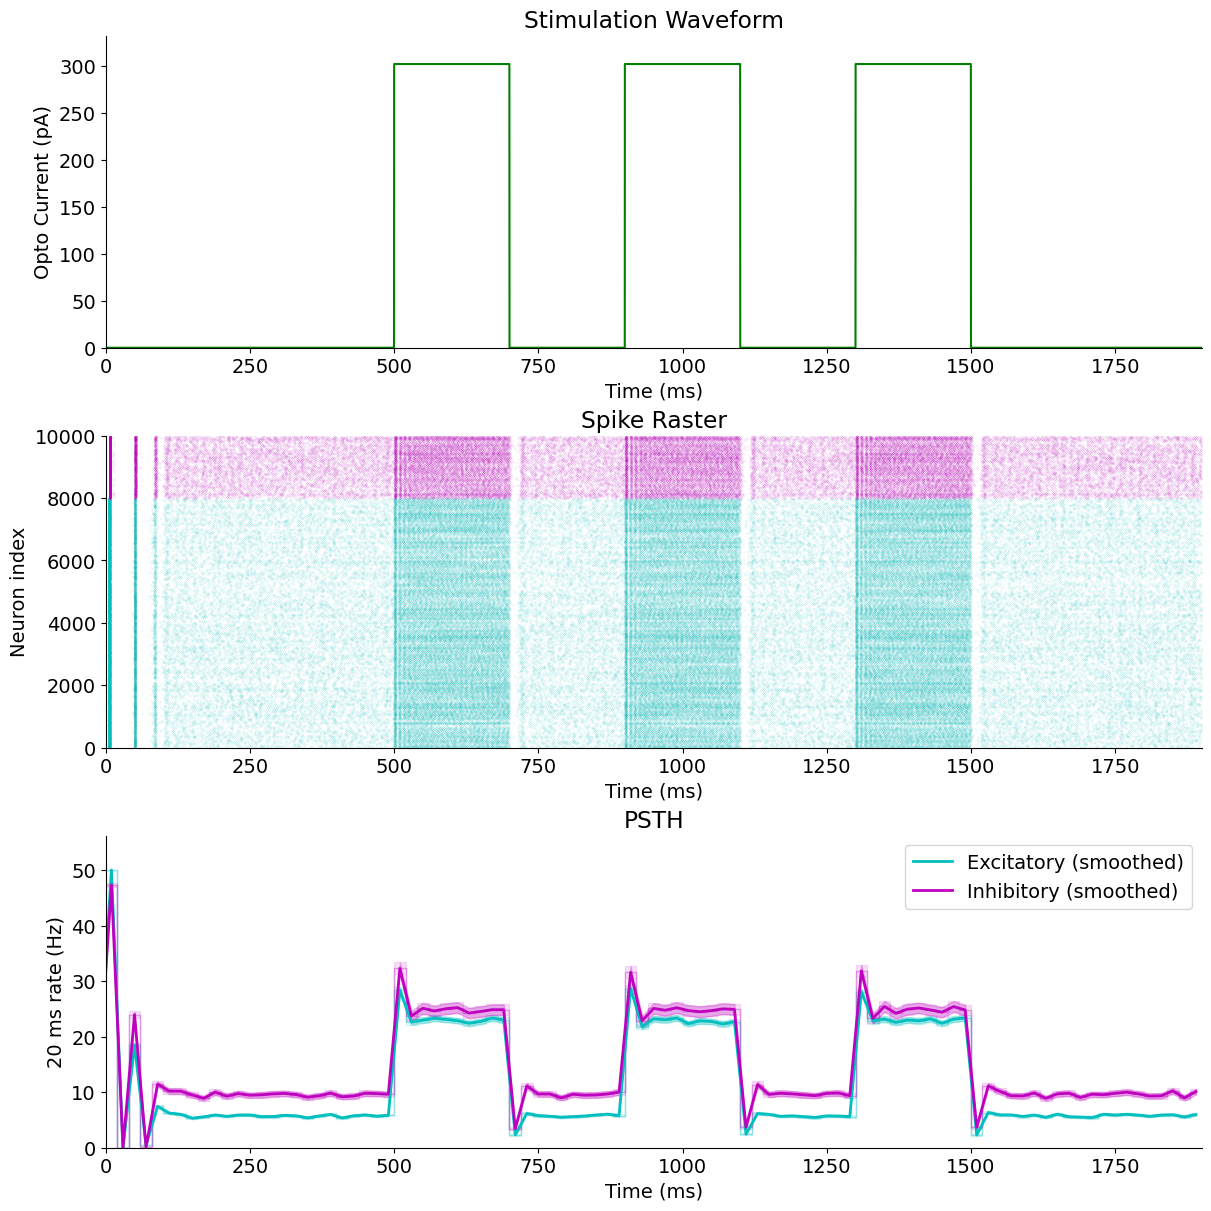

In [6]:
smooth_sigma_bins = 0.1  # std for Gaussian smoothing kernel (in bins)

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 12))

# --- PSTH binning ---
bin_size_ms = 20
bins = np.arange(0, t_total_ms + bin_size_ms, bin_size_ms)  # ms
bin_centers = (bins[:-1] + bins[1:]) / 2
n_bins = len(bin_centers)
bin_size_s = bin_size_ms / 1000

exc_mask = spike_indices < N_exc
inh_mask = spike_indices >= N_exc

# Per-neuron firing rates: shape (N_neurons, n_bins) — vectorised via add.at
bin_idx = np.digitize(spike_times, bins) - 1
valid = (bin_idx >= 0) & (bin_idx < n_bins)

exc_neuron_rates = np.zeros((N_exc, n_bins))
np.add.at(exc_neuron_rates,
          (spike_indices[exc_mask & valid].astype(int), bin_idx[exc_mask & valid]), 1)
exc_neuron_rates /= bin_size_s  # counts → Hz

inh_neuron_rates = np.zeros((N_inh, n_bins))
np.add.at(inh_neuron_rates,
          ((spike_indices[inh_mask & valid] - N_exc).astype(int), bin_idx[inh_mask & valid]), 1)
inh_neuron_rates /= bin_size_s

# Mean ± SEM (raw)
raw_exc = exc_neuron_rates.mean(axis=0)
sem_exc = exc_neuron_rates.std(axis=0, ddof=1) / np.sqrt(N_exc)
raw_inh = inh_neuron_rates.mean(axis=0)
sem_inh = inh_neuron_rates.std(axis=0, ddof=1) / np.sqrt(N_inh)

# Smooth each neuron's trace, then mean ± SEM
smoothed_exc_traces = gaussian_filter1d(exc_neuron_rates, smooth_sigma_bins, axis=1)
smoothed_exc = smoothed_exc_traces.mean(axis=0)
sem_smoothed_exc = smoothed_exc_traces.std(axis=0, ddof=1) / np.sqrt(N_exc)

smoothed_inh_traces = gaussian_filter1d(inh_neuron_rates, smooth_sigma_bins, axis=1)
smoothed_inh = smoothed_inh_traces.mean(axis=0)
sem_smoothed_inh = smoothed_inh_traces.std(axis=0, ddof=1) / np.sqrt(N_inh)

# Prepend zero padding for t < 0
plot_t = np.concatenate([[-bin_size_ms], bin_centers])
def prepend_zero(arr): return np.concatenate([[0], arr])

plot_raw_exc = prepend_zero(raw_exc);   plot_sem_exc = prepend_zero(sem_exc)
plot_raw_inh = prepend_zero(raw_inh);   plot_sem_inh = prepend_zero(sem_inh)
plot_exc = prepend_zero(smoothed_exc);  plot_sem_s_exc = prepend_zero(sem_smoothed_exc)
plot_inh = prepend_zero(smoothed_inh);  plot_sem_s_inh = prepend_zero(sem_smoothed_inh)

x_min, x_max = 0, t_total_ms

# --- Stimulation waveform ---
ax[0].set_title('Stimulation Waveform')
ax[0].plot(np.arange(n_timesteps_total) * dt_ms, stim_array, '-g')
ax[0].set_xlabel('Time (ms)')
ax[0].set_ylabel('Opto Current (pA)')
ax[0].set_xlim(x_min, x_max)
ax[0].set_ylim(0, stim_array.max() * 1.1)

# --- Raster plot ---
ax[1].set_title('Spike Raster')
ax[1].plot(spike_times[exc_mask], spike_indices[exc_mask], '.c', markersize=.1)
ax[1].plot(spike_times[inh_mask], spike_indices[inh_mask], '.m', markersize=.1)
ax[1].set_xlabel('Time (ms)')
ax[1].set_ylabel('Neuron index')
ax[1].set_xlim(x_min, x_max)
ax[1].set_ylim(-1, N_exc + N_inh)

# --- PSTH: binned + smoothed, both with SEM ---
ax[2].set_title('PSTH')
# Raw binned (step + SEM fill)
ax[2].step(plot_t, plot_raw_exc, where='mid', color='c', alpha=0.35, linewidth=1)
ax[2].step(plot_t, plot_raw_inh, where='mid', color='m', alpha=0.35, linewidth=1)
ax[2].fill_between(plot_t, plot_raw_exc - plot_sem_exc, plot_raw_exc + plot_sem_exc,
                   step='mid', color='c', alpha=0.12)
ax[2].fill_between(plot_t, plot_raw_inh - plot_sem_inh, plot_raw_inh + plot_sem_inh,
                   step='mid', color='m', alpha=0.12)
# Smoothed (line + SEM fill)
ax[2].plot(plot_t, plot_exc, '-c', linewidth=2, label=f'Excitatory (smoothed)')
ax[2].plot(plot_t, plot_inh, '-m', linewidth=2, label=f'Inhibitory (smoothed)')
ax[2].fill_between(plot_t, plot_exc - plot_sem_s_exc, plot_exc + plot_sem_s_exc, color='c', alpha=0.25)
ax[2].fill_between(plot_t, plot_inh - plot_sem_s_inh, plot_inh + plot_sem_s_inh, color='m', alpha=0.25)
ax[2].legend(loc='best')
ax[2].set_xlabel('Time (ms)')
ax[2].set_ylabel(f'{bin_size_ms} ms rate (Hz)')
ax[2].set_xlim(x_min, x_max)
ax[2].set_ylim(0, (max(plot_raw_exc.max(), plot_raw_inh.max()) + max(plot_sem_exc.max(), plot_sem_inh.max())) * 1.1)

# mark on regions used
fig.set_constrained_layout(True)

fig.savefig(fig_dir / 'psth_overview.png')
plt.show()

In [7]:
# Classify neurons by firing rate change: baseline (pre-stim) vs steady-state (during stim)
# Windows are derived from stim params and pooled across all 3 pulses.

t_pre_ms   = float(stim['t_pre_ms'])
t_pulse_ms = float(stim['t_pulse_ms'])
t_gap_ms   = float(stim['t_gap_ms'])
n_pulses   = int(stim['n_pulses'])

pulse_onsets  = [t_pre_ms + i * (t_pulse_ms + t_gap_ms) for i in range(n_pulses)]
pulse_offsets = [onset + t_pulse_ms for onset in pulse_onsets]

# Pre-stim baseline: last `pre_window_ms` before each pulse onset
pre_window_ms = 150
baseline_windows = [(onset - pre_window_ms, onset) for onset in pulse_onsets]

# Steady-state: last `ss_window_ms` of each pulse (skip the initial transient)
ss_window_ms = 150
ss_windows = [(offset - ss_window_ms, offset) for offset in pulse_offsets]

total_baseline_s = n_pulses * pre_window_ms / 1000
total_ss_s       = n_pulses * ss_window_ms / 1000

print('Baseline windows (ms):', [(f'{a:.0f}', f'{b:.0f}') for a, b in baseline_windows])
print('Steady-state windows (ms):', [(f'{a:.0f}', f'{b:.0f}') for a, b in ss_windows])

# Vectorised: build a (N_total, n_windows) mask per window, then sum
N_total = N_exc + N_inh

def pooled_rate(windows, total_duration_s):
    """Return firing rate (Hz) for every neuron, pooling spikes across all windows."""
    counts = np.zeros(N_total, dtype=float)
    for w_start, w_end in windows:
        in_win = (spike_times >= w_start) & (spike_times < w_end)
        np.add.at(counts, spike_indices[in_win].astype(int), 1)
    return counts / total_duration_s

baseline_all = pooled_rate(baseline_windows, total_baseline_s)
ss_all       = pooled_rate(ss_windows,       total_ss_s)

exc_baseline_rates = baseline_all[:N_exc]
inh_baseline_rates = baseline_all[N_exc:]
exc_ss_rates       = ss_all[:N_exc]
inh_ss_rates       = ss_all[N_exc:]

exc_diff = exc_ss_rates - exc_baseline_rates
inh_diff = inh_ss_rates - inh_baseline_rates

# Increaser / decreaser lists (used by the PSTH cell below)
exc_increasers = np.where(exc_diff > 0)[0].tolist()
exc_decreasers = np.where(exc_diff < 0)[0].tolist()
inh_increasers = (np.where(inh_diff > 0)[0] + N_exc).tolist()
inh_decreasers = (np.where(inh_diff < 0)[0] + N_exc).tolist()

print(f'Exc increasers: {len(exc_increasers)},  decreasers: {len(exc_decreasers)}')
print(f'Inh increasers: {len(inh_increasers)},  decreasers: {len(inh_decreasers)}')

Baseline windows (ms): [('350', '500'), ('750', '900'), ('1150', '1300')]
Steady-state windows (ms): [('550', '700'), ('950', '1100'), ('1350', '1500')]
Exc increasers: 3349,  decreasers: 2093
Inh increasers: 963,  decreasers: 553


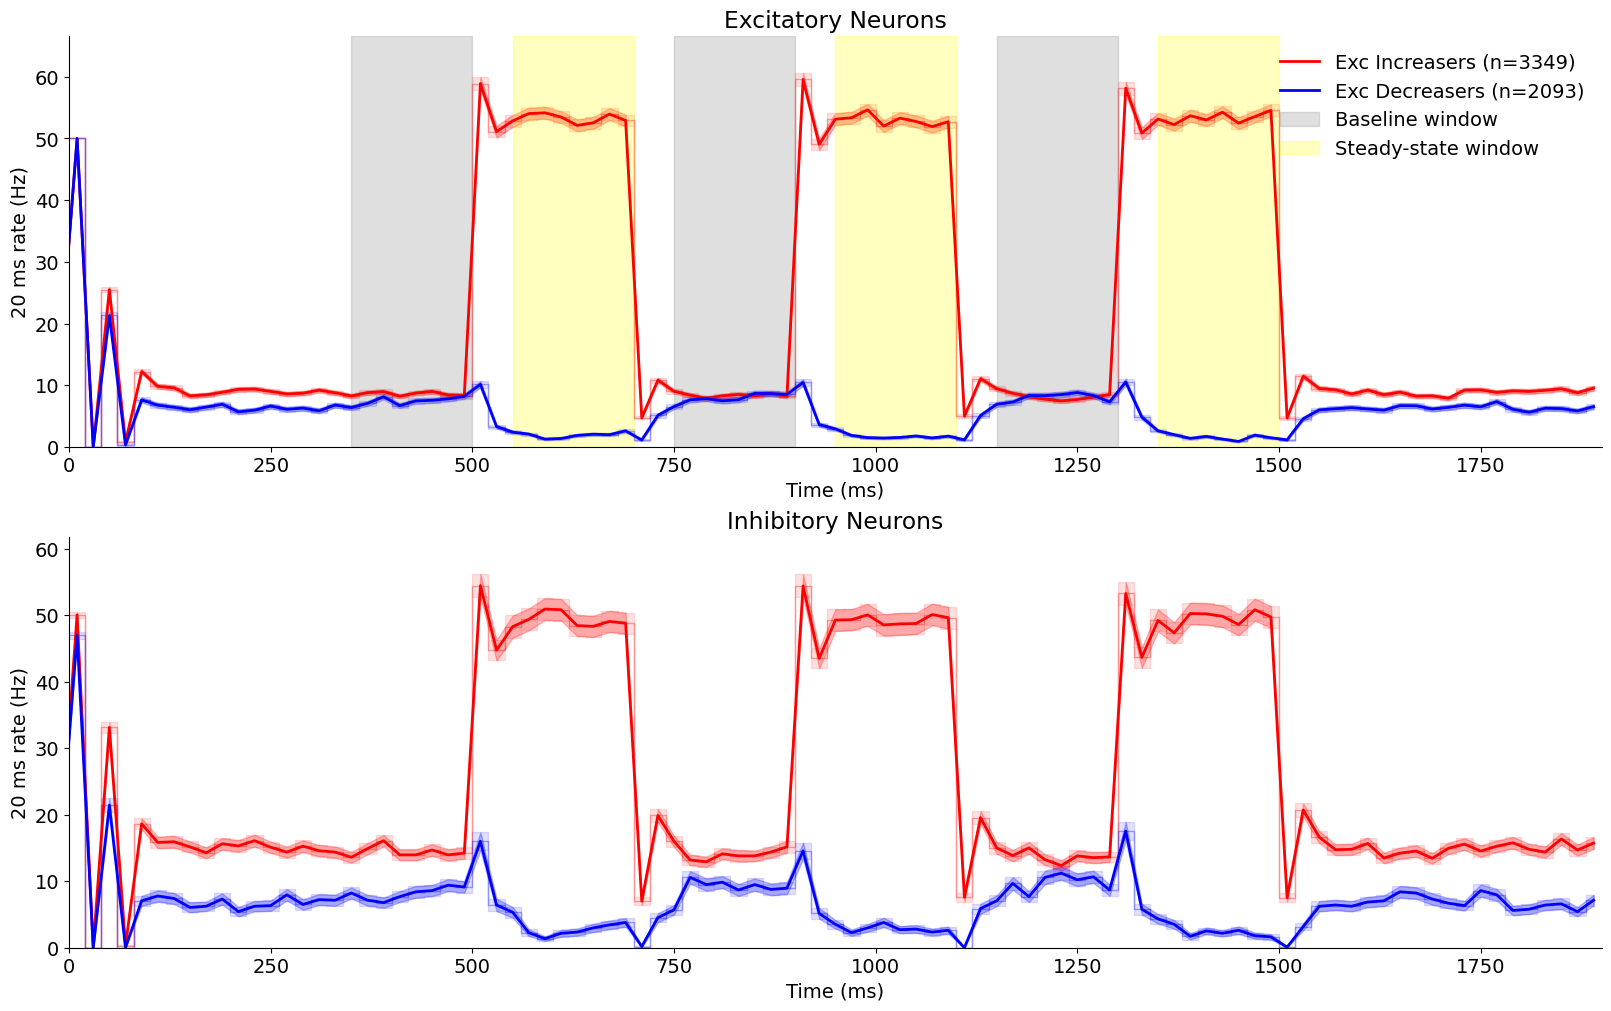

In [8]:
# plot combined PSTHs for groups that increase or decrease firing rate from baseline to steady state

def group_rates(neuron_ids, all_spike_times, all_spike_indices, bins, bin_size_s, smooth_sigma_bins):
    """Return (raw_mean, raw_sem, smooth_mean, smooth_sem) for a given group of neuron IDs."""
    n = len(neuron_ids)
    n_bins = len(bins) - 1
    neuron_rates = np.zeros((n, n_bins))
    for k, nid in enumerate(neuron_ids):
        counts, _ = np.histogram(all_spike_times[all_spike_indices == nid], bins=bins)
        neuron_rates[k] = counts / bin_size_s
    raw_mean = neuron_rates.mean(axis=0)
    raw_sem  = neuron_rates.std(axis=0, ddof=1) / np.sqrt(n)
    smoothed = gaussian_filter1d(neuron_rates, smooth_sigma_bins, axis=1)
    return raw_mean, raw_sem, smoothed.mean(axis=0), smoothed.std(axis=0, ddof=1) / np.sqrt(n)

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(16, 10))

for i, (inc_ids, dec_ids, pop_label) in enumerate([
    (exc_increasers, exc_decreasers, 'Excitatory'),
    (inh_increasers, inh_decreasers, 'Inhibitory'),
]):
    r_inc, s_inc, sm_inc, ss_inc = group_rates(inc_ids, spike_times, spike_indices, bins, bin_size_s, smooth_sigma_bins)
    r_dec, s_dec, sm_dec, ss_dec = group_rates(dec_ids, spike_times, spike_indices, bins, bin_size_s, smooth_sigma_bins)

    p_r_inc = prepend_zero(r_inc);  p_s_inc = prepend_zero(s_inc)
    p_r_dec = prepend_zero(r_dec);  p_s_dec = prepend_zero(s_dec)
    p_sm_inc = prepend_zero(sm_inc); p_ss_inc = prepend_zero(ss_inc)
    p_sm_dec = prepend_zero(sm_dec); p_ss_dec = prepend_zero(ss_dec)

    # Raw binned
    ax[i].step(plot_t, p_r_inc, where='mid', color='r', alpha=0.35, linewidth=1)
    ax[i].step(plot_t, p_r_dec, where='mid', color='b', alpha=0.35, linewidth=1)
    ax[i].fill_between(plot_t, p_r_inc - p_s_inc, p_r_inc + p_s_inc, step='mid', color='r', alpha=0.12)
    ax[i].fill_between(plot_t, p_r_dec - p_s_dec, p_r_dec + p_s_dec, step='mid', color='b', alpha=0.12)
    # Smoothed
    ax[i].plot(plot_t, p_sm_inc, '-r', linewidth=2, label=f'{pop_label[:3]} Increasers (n={len(inc_ids)})')
    ax[i].plot(plot_t, p_sm_dec, '-b', linewidth=2, label=f'{pop_label[:3]} Decreasers (n={len(dec_ids)})')
    ax[i].fill_between(plot_t, p_sm_inc - p_ss_inc, p_sm_inc + p_ss_inc, color='r', alpha=0.25)
    ax[i].fill_between(plot_t, p_sm_dec - p_ss_dec, p_sm_dec + p_ss_dec, color='b', alpha=0.25)
    ax[i].set_title(f'{pop_label} Neurons')
    ax[i].set_xlabel('Time (ms)')
    ax[i].set_ylabel(f'{bin_size_ms} ms rate (Hz)')
    ax[i].set_xlim(x_min, x_max)
    ax[i].set_ylim(0, max(p_r_inc.max() + p_s_inc.max(), p_r_dec.max() + p_s_dec.max()) * 1.1)

# Shade baseline and steady-state windows for all 3 pulses
for j, (bl_win, ss_win) in enumerate(zip(baseline_windows, ss_windows)):
    ax[0].axvspan(*bl_win, color='gray',   alpha=0.25, label='Baseline window'     if j == 0 else None)
    ax[0].axvspan(*ss_win, color='yellow', alpha=0.25, label='Steady-state window' if j == 0 else None)

ax[0].legend(loc='upper right', frameon=False)

fig.set_constrained_layout(True)
fig.savefig(fig_dir / 'increasers_decreasers_psth.png')
plt.show()

In [9]:
fig_dir

PosixPath('../results/random_ei_snn_pulses_lognormal_istim_orawe_params/20260414_155828/figures')

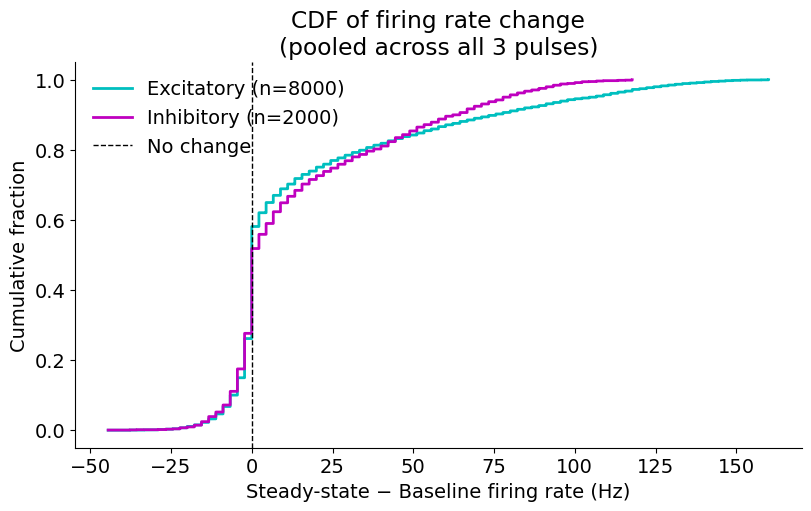

In [10]:
# CDF of per-neuron firing rate change (steady state − baseline), pooled across all 3 pulses

def ecdf(data):
    """Return (sorted_values, cumulative_fraction) for an empirical CDF."""
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

fig, ax = plt.subplots(figsize=(8, 5))

for diff, label, color in [
    (exc_diff, f'Excitatory (n={N_exc})', 'c'),
    (inh_diff, f'Inhibitory (n={N_inh})', 'm'),
]:
    x, y = ecdf(diff)
    ax.step(x, y, where='post', color=color, linewidth=2, label=label)

ax.axvline(0, color='k', linestyle='--', linewidth=1, label='No change')
ax.set_xlabel('Steady-state − Baseline firing rate (Hz)')
ax.set_ylabel('Cumulative fraction')
ax.set_title('CDF of firing rate change\n(pooled across all 3 pulses)')
ax.legend(loc='upper left', frameon=False)

fig.set_constrained_layout(True)
fig.savefig(fig_dir / 'cdf_rate_change.png', dpi=150)
plt.show()